## SECOM Data Set

**Dataset Link:** https://archive.ics.uci.edu/dataset/179/secom

---

### Overview
The SECOM dataset contains sensor data from a **semiconductor manufacturing process**, used to predict whether a product will **pass or fail** quality checks.

---

### Key Details
- **Instances:** 1567  
- **Features:** 591  
- **Type:** Multivariate (real-valued)  
- **Task:** Classification  
- **Missing Values:** Yes  
- **Labels:** `-1 = Pass`, `1 = Fail`  

---

### Objective
- Identify important sensors  
- Predict failures  
- Improve manufacturing efficiency  

---

### Challenges
- High dimensional data  
- Missing values  
- Class imbalance  
- Noisy and redundant features

## Libraries Used

- **NumPy, Pandas** → Data handling and numerical operations  
- **Matplotlib, Seaborn** → Data visualization  
- **Scikit-learn** → Model building and evaluation  
  - Train-test split, scaling, Random Forest  
  - Performance metrics and threshold tuning  
- **ipywidgets, IPython.display** → Interactive simulation in Jupyter  

These libraries support data preprocessing, model training, evaluation, and interactive analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
import ipywidgets as widgets
from IPython.display import display, clear_output

## Loading and Preparing Dataset

- Load the SECOM sensor data and corresponding labels from files  
- Check the dataset shape (rows = samples, columns = sensor data)  
- Rename sensor columns for better readability  
- Add the **pass/fail** label column to the dataset  

This step combines features and labels into a single structured DataFrame for further processing.

In [2]:
data=pd.read_csv("secom.data",sep=" ",header=None)
labels=pd.read_csv("secom_labels.data",sep=" ",header=None)
print("Number of rows and columns:",data.shape)

data=data.add_prefix("Sensor_")
data["pass/fail"]=labels[0]
print(data.head())

Number of rows and columns: (1567, 590)
   Sensor_0  Sensor_1   Sensor_2   Sensor_3  Sensor_4  Sensor_5  Sensor_6  \
0   3030.93   2564.00  2187.7333  1411.1265    1.3602     100.0   97.6133   
1   3095.78   2465.14  2230.4222  1463.6606    0.8294     100.0  102.3433   
2   2932.61   2559.94  2186.4111  1698.0172    1.5102     100.0   95.4878   
3   2988.72   2479.90  2199.0333   909.7926    1.3204     100.0  104.2367   
4   3032.24   2502.87  2233.3667  1326.5200    1.5334     100.0  100.3967   

   Sensor_7  Sensor_8  Sensor_9  ...  Sensor_581  Sensor_582  Sensor_583  \
0    0.1242    1.5005    0.0162  ...         NaN      0.5005      0.0118   
1    0.1247    1.4966   -0.0005  ...    208.2045      0.5019      0.0223   
2    0.1241    1.4436    0.0041  ...     82.8602      0.4958      0.0157   
3    0.1217    1.4882   -0.0124  ...     73.8432      0.4990      0.0103   
4    0.1235    1.5031   -0.0031  ...         NaN      0.4800      0.4766   

   Sensor_584  Sensor_585  Sensor_586  S

## Data Cleaning and Preprocessing

- Remove sensor columns with more than **50% missing values**  
- Fill remaining missing values using the **mean of each column**  
- Convert labels:
  - `-1 → 1` (Pass)  
  - `1 → 0` (Fail)  

This step ensures the dataset is clean and consistent.

In [3]:
clean_data=data
for i in data.columns:
    nancount=data.shape[0]-data[i].count()
    if(nancount>0.5*data.shape[0]):
        clean_data=clean_data.drop(i,axis=1)
for i in clean_data.columns:
    clean_data[i]=clean_data[i].fillna(clean_data[i].mean())
clean_data["pass/fail"]=data["pass/fail"].replace({-1:1, 1:0})
print("Cleaned Data:\n",clean_data)

Cleaned Data:
       Sensor_0  Sensor_1   Sensor_2   Sensor_3  Sensor_4  Sensor_5  Sensor_6  \
0      3030.93   2564.00  2187.7333  1411.1265    1.3602     100.0   97.6133   
1      3095.78   2465.14  2230.4222  1463.6606    0.8294     100.0  102.3433   
2      2932.61   2559.94  2186.4111  1698.0172    1.5102     100.0   95.4878   
3      2988.72   2479.90  2199.0333   909.7926    1.3204     100.0  104.2367   
4      3032.24   2502.87  2233.3667  1326.5200    1.5334     100.0  100.3967   
...        ...       ...        ...        ...       ...       ...       ...   
1562   2899.41   2464.36  2179.7333  3085.3781    1.4843     100.0   82.2467   
1563   3052.31   2522.55  2198.5667  1124.6595    0.8763     100.0   98.4689   
1564   2978.81   2379.78  2206.3000  1110.4967    0.8236     100.0   99.4122   
1565   2894.92   2532.01  2177.0333  1183.7287    1.5726     100.0   98.7978   
1566   2944.92   2450.76  2195.4444  2914.1792    1.5978     100.0   85.1011   

      Sensor_7  Sensor_8

## Class Distribution

- Count the number of **Pass** and **Fail** samples  
- Visualize the class distribution using a bar plot  

This helps identify **class imbalance**, which is important for model training and evaluation.

pass/fail
1    1463
0     104
Name: count, dtype: int64


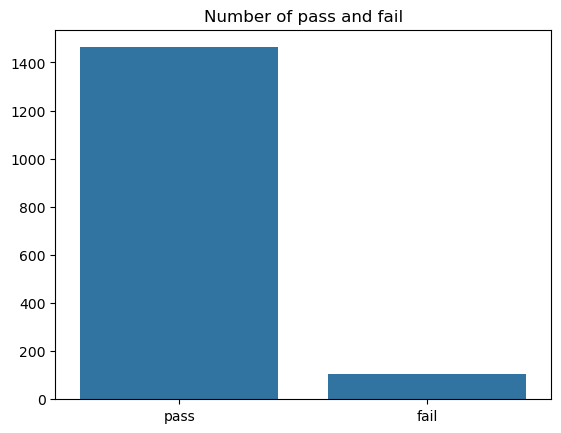

In [4]:
passfailcount=clean_data["pass/fail"].value_counts()
print(passfailcount)
sns.barplot(x=["pass","fail"],y=passfailcount.values)
plt.title("Number of pass and fail")
plt.show()

## Model Preparation and Training

- Separate features (**X**) and target (**y**)  
- Split data into **training (75%)** and **testing (25%)** sets using stratification  
- Standardize features using **StandardScaler**  
- Train a **Random Forest Classifier** with class weighting to handle imbalance  
- Extract and display the **top 10 most important sensors**  

This step builds the predictive model and identifies the most influential features for failure detection.

In [5]:
X = clean_data.select_dtypes(include=[np.number]).drop("pass/fail", axis=1)
y = clean_data["pass/fail"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_full_scaled=scaler.transform(X)

model = RandomForestClassifier(
    n_estimators=5000,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=4,
    max_features=0.6,
    class_weight={0:4, 1:1}, 
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

importance = pd.Series(model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(10)

print("\nTop 10 Important Sensors:\n", top_features)


Top 10 Important Sensors:
 Sensor_59     0.080633
Sensor_341    0.016662
Sensor_103    0.015835
Sensor_16     0.012735
Sensor_477    0.011473
Sensor_64     0.010886
Sensor_582    0.009790
Sensor_0      0.009396
Sensor_205    0.009395
Sensor_348    0.008872
dtype: float64


## Summary Statistics of Important Sensors

- Display descriptive statistics for each of the **top important sensors**  
- Includes metrics like **mean, standard deviation, min, max, and quartiles**  

This helps understand the distribution and range of the most influential features in the model.

In [6]:
for i in top_features.index:
    print("\n",clean_data[i].describe())


 count    1567.000000
mean        2.960241
std         9.510891
min       -28.988200
25%        -1.855450
50%         0.973600
75%         4.337700
max       168.145500
Name: Sensor_59, dtype: float64

 count    1567.000000
mean        2.732094
std         3.660869
min         0.574100
25%         1.914250
50%         2.385300
75%         2.984400
max        97.708900
Name: Sensor_341, dtype: float64

 count    1567.000000
mean       -0.009789
std         0.003063
min        -0.032900
25%        -0.011800
50%        -0.010100
75%        -0.008200
max         0.020300
Name: Sensor_103, dtype: float64

 count    1567.000000
mean        9.907603
std         2.401563
min         4.469600
25%         9.568550
50%         9.852000
75%        10.127750
max       102.867700
Name: Sensor_16, dtype: float64

 count    1567.000000
mean        6.257921
std        10.165496
min         1.687200
25%         4.111500
50%         5.254600
75%         6.699750
max       289.826400
Name: Sensor_477, dt

## Distribution of Important Sensors

- Plot histograms for each **top important sensor**  
- Compare distributions for **Pass vs Fail** using color coding  
- Helps visualize how sensor values differ between outcomes  

This aids in understanding which sensors show clear separation between failing and non-failing machines.

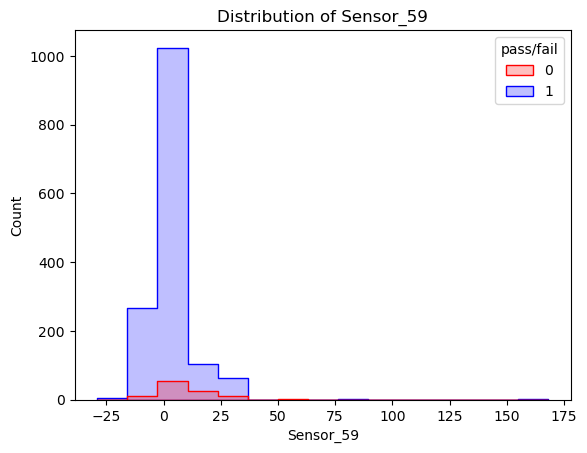

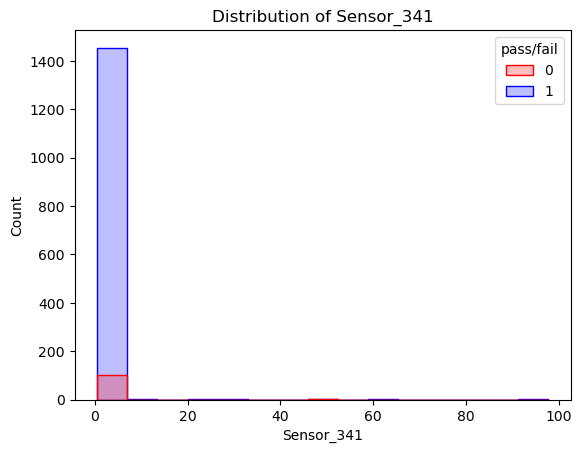

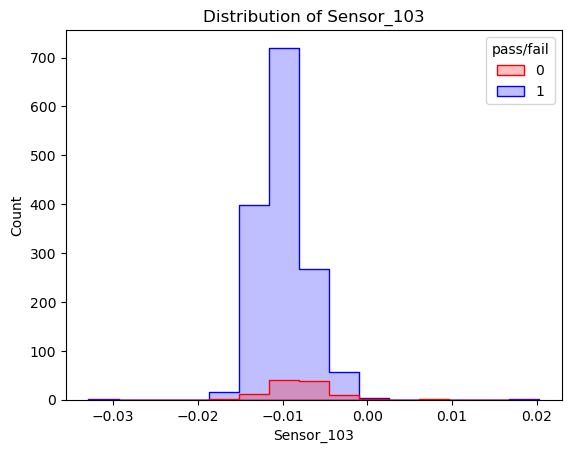

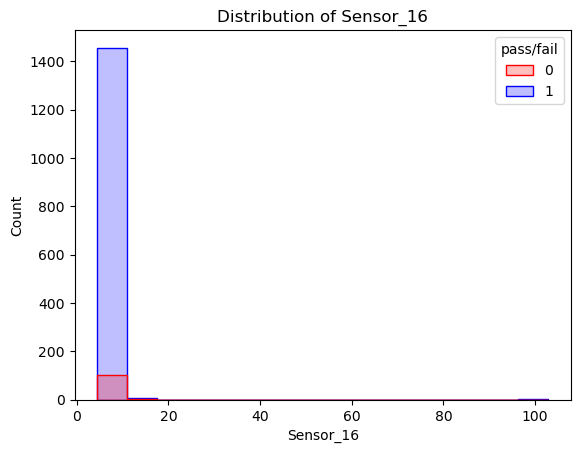

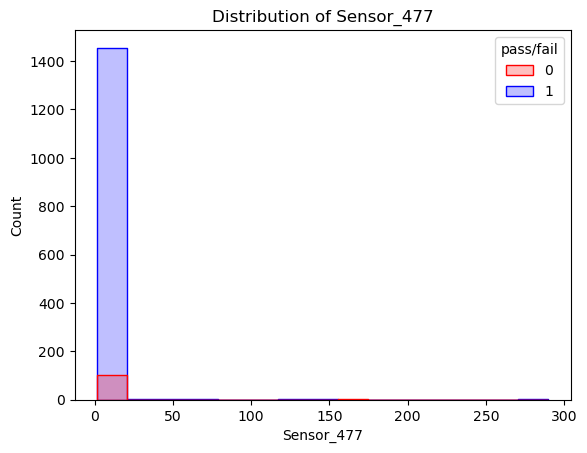

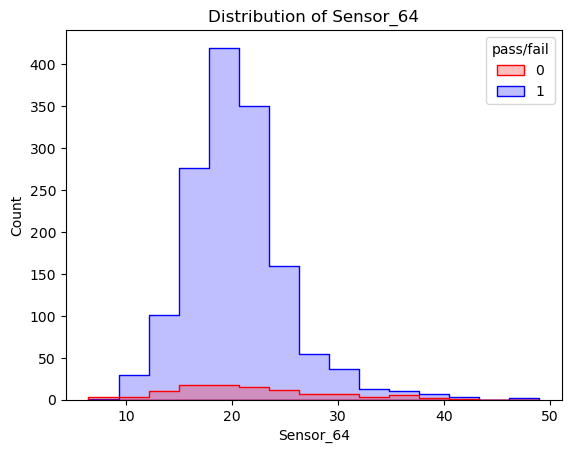

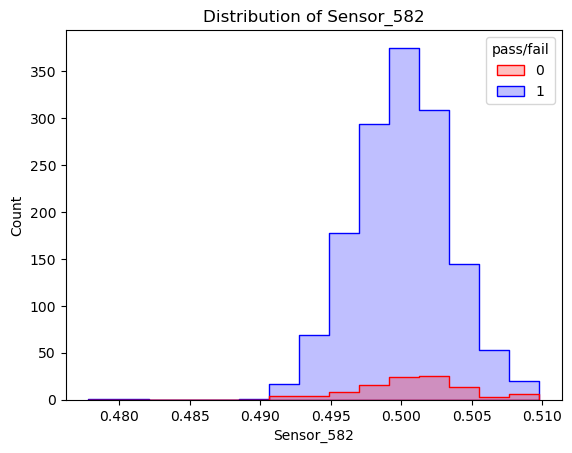

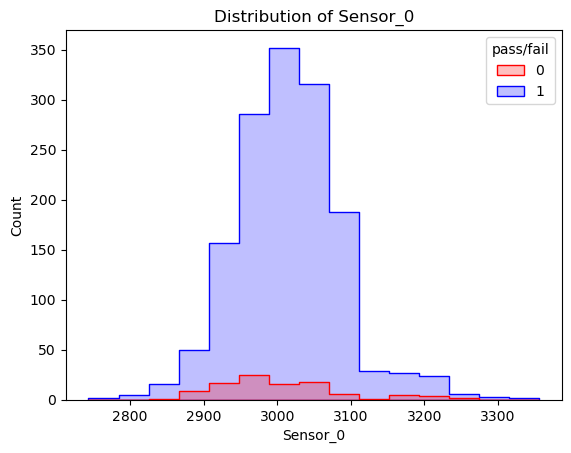

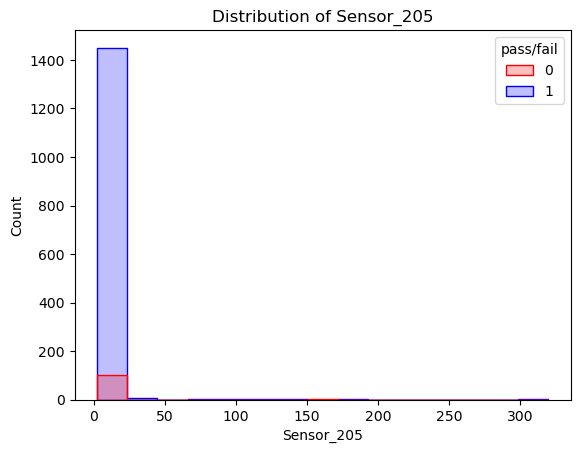

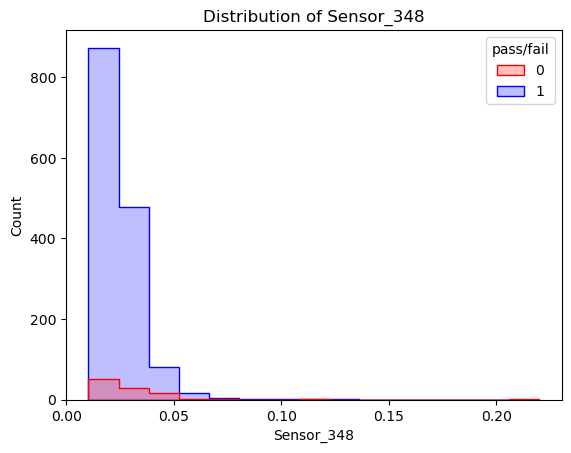

In [7]:
for sensor in top_features.index:
    plt.figure()
    sns.histplot(data=clean_data, x=sensor, hue="pass/fail", 
                 bins=15, palette={0: "red", 1: "blue"},
                 element="step")
    plt.title(f"Distribution of {sensor}")
    plt.show()

## Boxplot Analysis of Important Sensors

- Visualize each **top sensor** using boxplots  
- Compare distributions across **Fail vs Pass classes**  
- Highlights differences in median, spread, and outliers  

This helps identify sensors that clearly distinguish failing machines from normal ones.

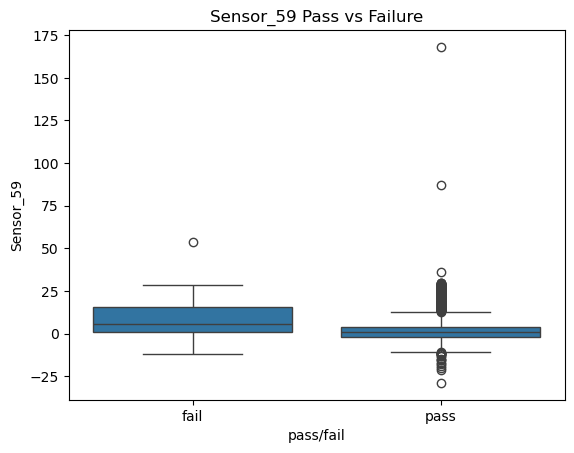

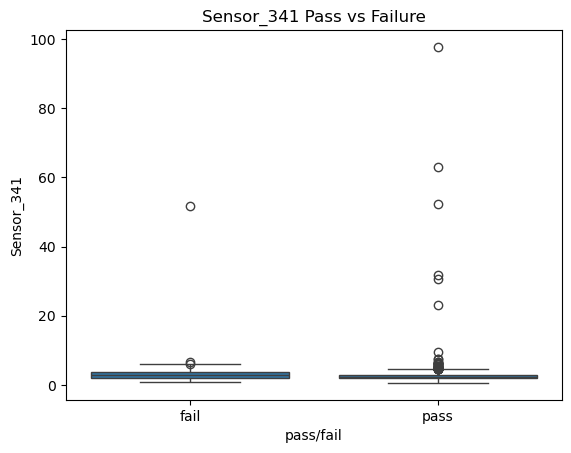

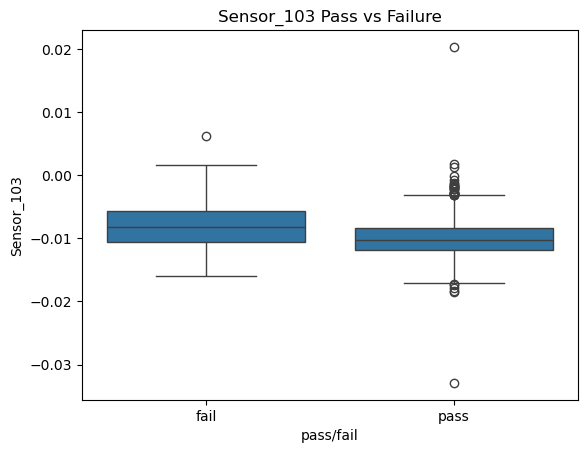

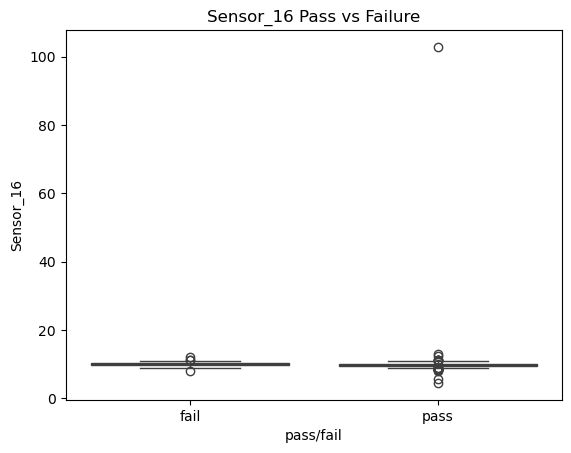

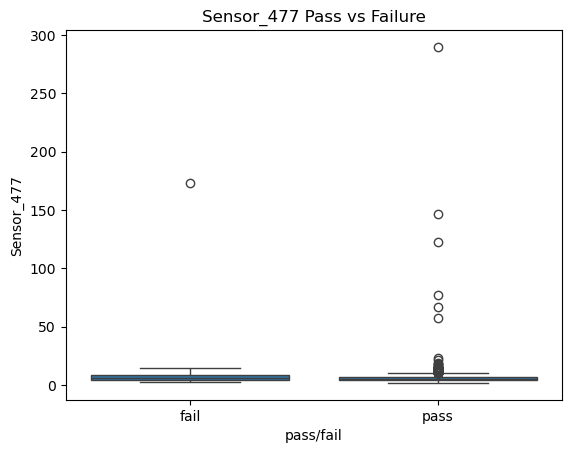

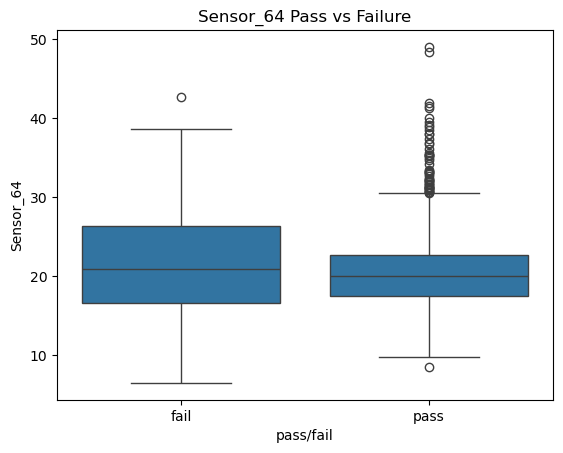

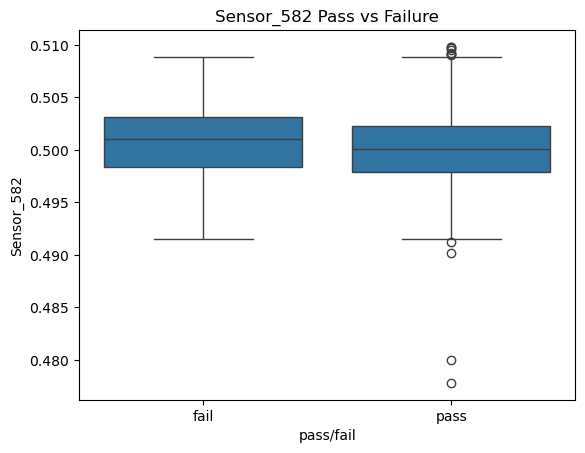

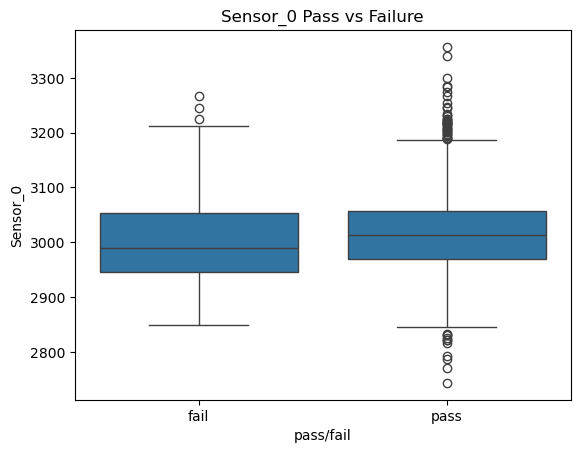

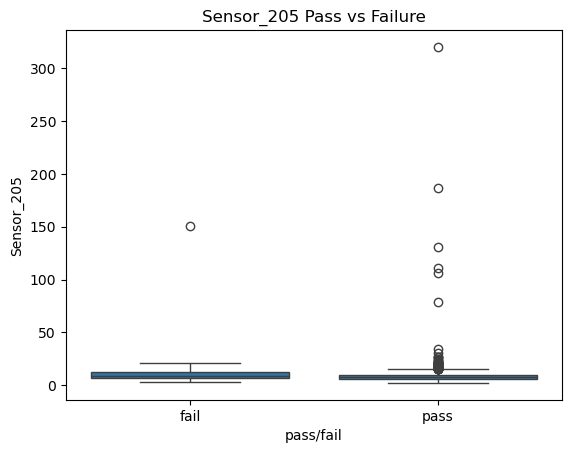

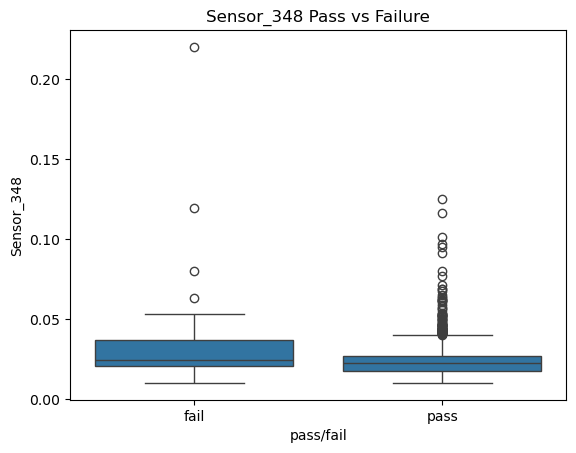

In [8]:
for sensor in top_features.index:
    plt.figure()
    sns.boxplot(x=clean_data["pass/fail"],y=clean_data[sensor])
    plt.xticks([0,1],["fail","pass"])
    plt.title(f"{sensor} Pass vs Failure")
    plt.show()

## Correlation Between Important Sensors

- Compute correlation between the **top important sensors**  
- Visualize using a **heatmap**  
- Helps identify relationships between sensors (positive or negative correlation)  

This is useful to detect redundancy and understand how sensors influence each other.

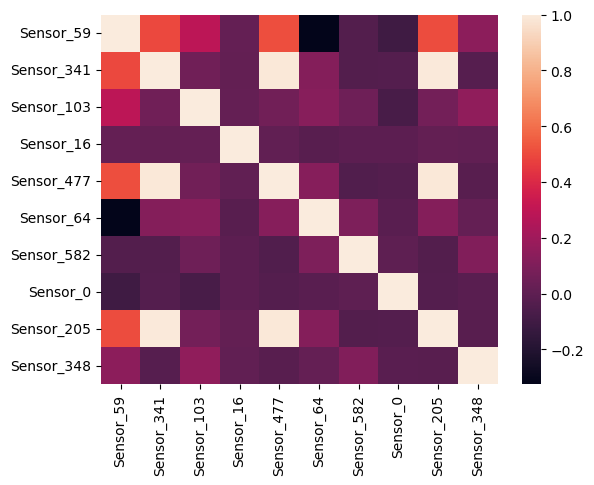

In [10]:
feature_corr=clean_data[top_features.index].corr()
sns.heatmap(feature_corr)
plt.show()